Tổng số ảnh thực tế trong file CSV của tôi là: 20
Đang huấn luyện mô hình Random Forest...

KẾT QUẢ ĐỂ ĐIỀN VÀO BÁO CÁO
Độ chính xác (Accuracy): 60.00%
True Positive (Đoán đúng Chó - Thực tế Chó, Máy đoán Chó): 4
True Negative (Đoán đúng Mèo - Thực tế Mèo, Máy đoán Mèo): 2
False Positive (Nhầm Mèo thành Chó - Thực tế Mèo, Máy đoán Chó): 3
False Negative (Nhầm Chó thành Mèo - Thực tế Chó, Máy đoán Mèo): 1


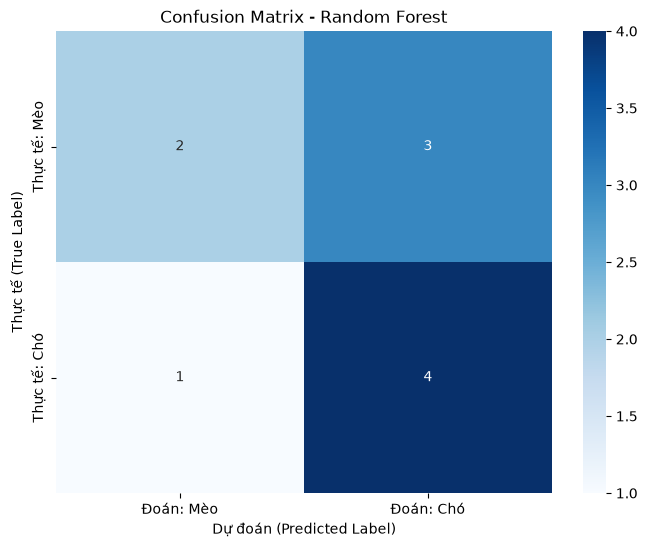

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Đọc dữ liệu từ file CSV đã được tạo ra
csv_path = '../data/dog_cat_features.csv'
try:
    df = pd.read_csv(csv_path)
    print(f"Tổng số ảnh thực tế trong file CSV của tôi là: {len(df)}")
except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy file {csv_path}. Hãy chạy file trích xuất đặc trưng trước!")
    exit()

# 2. Tách Features (X) và Label (y)
X = df.drop('Label', axis=1) # Lấy tất cả các cột trừ cột nhãn
y = df['Label']              # Cột chứa chữ 'dog' hoặc 'cat'

# Chuyển nhãn dạng chữ sang dạng số (Cat = 0, Dog = 1) để dễ hiển thị Confusion Matrix
y_numeric = y.map({'cat': 0, 'dog': 1})

# 3. Chia tập dữ liệu (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y_numeric, test_size=0.5, random_state=42, stratify=y_numeric)

# 4. Huấn luyện mô hình Random Forest (với 100 cây quyết định theo nguyên lý)
print("Đang huấn luyện mô hình Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Dự đoán trên tập Test
y_pred = rf_model.predict(X_test)

# 6. Đánh giá kết quả (Tính Accuracy và Confusion Matrix)
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred) # Labels mặc định là [0 (Cat), 1 (Dog)]

# Giải nén các giá trị từ Confusion Matrix
TN, FP, FN, TP = cm.ravel()

print("\n" + "="*40)
print("KẾT QUẢ ĐỂ ĐIỀN VÀO BÁO CÁO")
print("="*40)
print(f"Độ chính xác (Accuracy): {accuracy * 100:.2f}%")
print(f"True Positive (Đoán đúng Chó - Thực tế Chó, Máy đoán Chó): {TP}")
print(f"True Negative (Đoán đúng Mèo - Thực tế Mèo, Máy đoán Mèo): {TN}")
print(f"False Positive (Nhầm Mèo thành Chó - Thực tế Mèo, Máy đoán Chó): {FP}")
print(f"False Negative (Nhầm Chó thành Mèo - Thực tế Chó, Máy đoán Mèo): {FN}")
print("="*40)

# 7. Vẽ và lưu hình ảnh Confusion Matrix
plt.figure(figsize=(8, 6))
# Dùng seaborn để vẽ biểu đồ nhiệt (heatmap) cho đẹp
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Đoán: Mèo', 'Đoán: Chó'], 
            yticklabels=['Thực tế: Mèo', 'Thực tế: Chó'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Thực tế (True Label)')
plt.xlabel('Dự đoán (Predicted Label)')

plt.show()